In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
import leidenalg
import squidpy as sq
from scipy import sparse
from matplotlib.colors import ListedColormap
import os
import seaborn as sns
import geopandas as gpd
from scipy.io import mmread
from scipy.spatial import distance
import ot
from sklearn.cluster import KMeans
from collections import Counter
import os

2025-04-02 17:54:21.134507: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-02 17:54:21.165827: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-02 17:54:21.175504: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-02 17:54:23.138908: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def compute_kmeans_centroids(adata, cell_type_col="cell_type", min_centroids = 100):
    """
    Performs K-means clustering on gene expression data (adata.X) for each cell type, 
    using the least frequent cell type count as k.
    
    Parameters:
        adata: AnnData
            The AnnData object containing gene expression data and cell types.
        cell_type_col: str
            Column in `adata.obs` indicating cell types.

    Returns:
        centroids_dict: dict
            Dictionary where keys are cell types and values are their K-means centroids.
    """
    # Count occurrences of each cell type
    cell_type_counts = adata.obs[cell_type_col].value_counts()
    
    # Determine the least frequent cell type count (this is used as k)
    k = min_centroids
    
    # Dictionary to store centroids
    centroids_dict = {}

    # Loop through each cell type and perform K-means clustering
    for cell_type in cell_type_counts.index:
        # Select cells of the current cell type
        cell_mask = adata.obs[cell_type_col] == cell_type
        cell_data = adata[cell_mask].X  # Extract gene expression data

        # Check if there are enough cells to perform clustering
        if cell_data.shape[0] >= k:
            # Perform K-means clustering
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans.fit(cell_data)
            centroids = kmeans.cluster_centers_

            # Store centroids
            centroids_dict[cell_type] = centroids
        else:
            print(f"Skipping {cell_type}, not enough cells for k-means (required: {k}, found: {cell_data.shape[0]})")
            centroids_dict[cell_type] = cell_data


    return centroids_dict

def convert_centroids_to_anndata(centroids_dict):
    """
    Converts the K-means centroids dictionary into an AnnData object.

    Parameters:
        centroids_dict: dict
            Dictionary where keys are cell types and values are K-means centroids.

    Returns:
        adata_centroids: AnnData
            AnnData object with centroids as expression values and cell types as metadata.
    """
    # Prepare data for AnnData
    centroid_list = []
    cell_type_list = []

    for cell_type, centroids in centroids_dict.items():
        centroid_list.append(centroids)  # Collect all centroids
        cell_type_list.extend([cell_type] * centroids.shape[0])  # Assign cell type labels

    # Convert lists to NumPy array and Pandas DataFrame
    X = np.vstack(centroid_list)  # Stack all centroids into a single NumPy array
    obs = pd.DataFrame({"cell_type": cell_type_list})  # Create cell type metadata

    # Create AnnData object
    adata_centroids = anndata.AnnData(X=X, obs=obs)

    return adata_centroids


In [3]:
sample = "Pat02_W4"

In [4]:
#read txt file
def read_txt(file_path):
    data = pd.read_csv(file_path, sep='\t', header=0, index_col=0)
    return data

singlecell = read_txt('/home3/ciervo/scMULTIOME/Matrici/' + sample + '_NormData.txt')
singlecell = singlecell.T
singlecell.shape

(6910, 28488)

In [5]:
singlecell.head()

genes,MIR1302-2HG,OR4F5,AL627309.1,AL627309.5,AP006222.2,AL669831.2,LINC01409,FAM87B,LINC01128,LINC00115,...,AC011841.1,AL354822.1,AL592183.1,AC240274.1,AC004556.3,AC136612.1,AC136616.1,AC023491.2,AC007325.4,AC007325.2
Pat02_W4_AAACAGCCAACCGCCA.1,0.0,0.0,0.0,0.0,0.0,0.0,0.808369,0.0,0.808369,0.000000,...,0.0,0.0,1.249469,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Pat02_W4_AAACAGCCAATGCCTA.1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Pat02_W4_AAACAGCCACCACAAC.1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Pat02_W4_AAACAGCCAGCAAGTG.1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,1.000192,...,0.0,0.0,1.000192,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Pat02_W4_AAACAGCCAGCCTTGG.1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.582450,0.000000,...,0.0,0.0,0.333045,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
annotations = read_txt('/home3/ciervo/scMULTIOME/Matrici/' + sample + '_annotation.txt')
annotations.shape
annotations.head()

,Cell_annotation,Metaprogram_assignment
Barcode,,
AAACAGCCAACCGCCA-1,Malignant,MP_4
AAACAGCCAATGCCTA-1,Endothelial cells,NaN
AAACAGCCACCACAAC-1,Malignant,MP_4
AAACAGCCAGCAAGTG-1,Malignant,non-classified
AAACAGCCAGCCTTGG-1,Malignant,MP_4


In [7]:
#create anndata object
scadata = anndata.AnnData(singlecell)
scadata.obs = annotations
scadata.obs["cell_type"] = np.where(scadata.obs["Cell_annotation"] != "Malignant",  
                                    scadata.obs["Cell_annotation"], scadata.obs["Metaprogram_assignment"])

In [8]:
scadata.obs["cell_type"].value_counts()

MP_4                          3255
non-classified                1138
MP_1                          1058
MP_7                           333
MP_3                           297
M1 macrophages                 197
Endothelial cells              181
myoCAF                          90
Keratinocytes                   72
iCAF                            67
Cycling cells                   59
T cells - Tregs                 51
MP_6                            51
M2 macrophages                  16
T cells - CD4 Tcm               16
MP_2                            15
T cells - CD4                    4
MP_5                             3
B cells                          3
T cells - Exhausted T cell       2
T cells - CD8 Tcm                2
Name: cell_type, dtype: int64

In [9]:
#remove "non-classified"
scadata = scadata[scadata.obs["cell_type"]!="non-classified"]
scadata = scadata[scadata.obs["cell_type"]!="Cycling cells"]

In [10]:
scadata.obs["cell_type"].value_counts()

MP_4                          3255
MP_1                          1058
MP_7                           333
MP_3                           297
M1 macrophages                 197
Endothelial cells              181
myoCAF                          90
Keratinocytes                   72
iCAF                            67
T cells - Tregs                 51
MP_6                            51
M2 macrophages                  16
T cells - CD4 Tcm               16
MP_2                            15
T cells - CD4                    4
MP_5                             3
B cells                          3
T cells - Exhausted T cell       2
T cells - CD8 Tcm                2
Name: cell_type, dtype: int64

In [11]:
# #if starts with T cells, rename to T cells
# scadata.obs["cell_type"] = np.where(scadata.obs["cell_type"].str.startswith("T cells"), "T cells", scadata.obs["cell_type"])
# scadata.obs["cell_type"] = np.where(scadata.obs["cell_type"].str.startswith("M1 mac"), "Macrophages", scadata.obs["cell_type"])
# scadata.obs["cell_type"] = np.where(scadata.obs["cell_type"].str.startswith("M2 mac"), "Macrophages", scadata.obs["cell_type"])
# scadata.obs["cell_type"] = np.where(scadata.obs["cell_type"].str.startswith("iCAF"), "CAF", scadata.obs["cell_type"])
# scadata.obs["cell_type"] = np.where(scadata.obs["cell_type"].str.startswith("myoCAF"), "CAF", scadata.obs["cell_type"])
# scadata.obs["cell_type"] = np.where(scadata.obs["cell_type"].str.startswith("B cells"), "Plasma cells", scadata.obs["cell_type"])
# scadata.obs["cell_type"].value_counts()

In [12]:
centroids_dict = compute_kmeans_centroids(scadata)

Skipping myoCAF, not enough cells for k-means (required: 100, found: 90)
Skipping Keratinocytes, not enough cells for k-means (required: 100, found: 72)
Skipping iCAF, not enough cells for k-means (required: 100, found: 67)
Skipping T cells - Tregs, not enough cells for k-means (required: 100, found: 51)
Skipping MP_6, not enough cells for k-means (required: 100, found: 51)
Skipping M2 macrophages, not enough cells for k-means (required: 100, found: 16)
Skipping T cells - CD4 Tcm, not enough cells for k-means (required: 100, found: 16)
Skipping MP_2, not enough cells for k-means (required: 100, found: 15)
Skipping T cells - CD4, not enough cells for k-means (required: 100, found: 4)
Skipping MP_5, not enough cells for k-means (required: 100, found: 3)
Skipping B cells, not enough cells for k-means (required: 100, found: 3)
Skipping T cells - Exhausted T cell, not enough cells for k-means (required: 100, found: 2)
Skipping T cells - CD8 Tcm, not enough cells for k-means (required: 100, 

In [13]:
adata_centroids = convert_centroids_to_anndata(centroids_dict)
adata_centroids.var_names = scadata.var_names
scadata = adata_centroids
scadata

/home/fceccarelli/miniconda3/envs/visium/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 992 × 28488
    obs: 'cell_type'

In [14]:
scadata.obs["cell_type"].value_counts()

MP_4                          100
MP_1                          100
MP_7                          100
MP_3                          100
M1 macrophages                100
Endothelial cells             100
myoCAF                         90
Keratinocytes                  72
iCAF                           67
T cells - Tregs                51
MP_6                           51
M2 macrophages                 16
T cells - CD4 Tcm              16
MP_2                           15
T cells - CD4                   4
MP_5                            3
B cells                         3
T cells - Exhausted T cell      2
T cells - CD8 Tcm               2
Name: cell_type, dtype: int64

In [15]:
tumor_sc = scadata[scadata.obs["cell_type"].str.startswith("MP"), :]
tme_sc = scadata[~scadata.obs["cell_type"].str.startswith("MP"), :]

In [16]:
sample = "Pat2_W4"
um = '008'
data_directory = "../segmentation/" + sample 
spadata = anndata.read_h5ad(data_directory + "/" + sample + "_" + um + "_processed.h5ad")
spadata

AnnData object with n_obs × n_vars = 57524 × 15181
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'percent_mito', 'leiden', 'cell_type', 'cell_annotation'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'mean', 'std'
    uns: 'cell_annotation_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [17]:
spadata.obs["cell_type"].value_counts()

TME            38202
Melanocytes    19322
Name: cell_type, dtype: int64

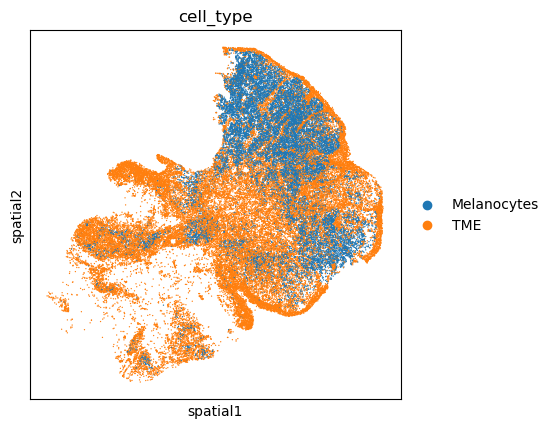

In [18]:
sc.pl.spatial(spadata, color='cell_type', spot_size=100)  

In [19]:
tumor_sp = spadata[spadata.obs['cell_type'] == 'Melanocytes']
tme_sp = spadata[spadata.obs['cell_type'] != 'Melanocytes']

In [20]:
def perform_OT(scell, sp, alpha = 0.2):


    common_genes = scell.var.index.intersection(sp.var.index)
    scell = scell[:, common_genes].copy() 
    sp = sp[:, common_genes].copy()
    joint_adata = anndata.concat([scell, sp], axis=0)
    sc.pp.pca(joint_adata, 50)
    joint_datamatrix = joint_adata.obsm['X_pca']
    X = joint_datamatrix[:scell.shape[0], :]
    Y = joint_datamatrix[scell.shape[0]:, :]

    M = distance.cdist(X, Y)

    C1 = distance.cdist(X, X)
    C2 = distance.cdist(sp.obsm["spatial"], sp.obsm["spatial"])

    C1 = C1.astype(float)
    C2 = C2.astype(float)
    M = M.astype(float)

    print ("Shape of the matrices C1, C2, M")
    print (C1.shape, C2.shape, M.shape)

    C1 /= C1.max()
    C2 /= C2.max()
    M /= M.max()

    p = ot.unif(X.shape[0])
    q = ot.unif(Y.shape[0])

    print ("Computing transport for alpha = ", round(alpha, 1))
    T = ot.gromov.entropic_fused_gromov_wasserstein(M, C1, C2, alpha = alpha, p = p, q = q, verbose = False)
    return T

In [21]:
T_tme = perform_OT(tme_sc, tme_sp)
max_indices = np.argmax(T_tme, axis=0)  
spot_annotations = tme_sc.obs["cell_type"][max_indices]
tme_sp.obs["cell_type"] = np.array(spot_annotations)

Shape of the matrices C1, C2, M
(523, 523) (38202, 38202) (523, 38202)
Computing transport for alpha =  0.2


/tmp/ipykernel_1009608/3945851828.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  tme_sp.obs["cell_type"] = np.array(spot_annotations)


In [22]:
T_tumor = perform_OT(tumor_sc, tumor_sp)
max_indices = np.argmax(T_tumor, axis=0)  
spot_annotations = tumor_sc.obs["cell_type"][max_indices]
tumor_sp.obs["cell_type"] = np.array(spot_annotations)

Shape of the matrices C1, C2, M
(469, 469) (19322, 19322) (469, 19322)
Computing transport for alpha =  0.2


/tmp/ipykernel_1009608/2148832797.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  tumor_sp.obs["cell_type"] = np.array(spot_annotations)


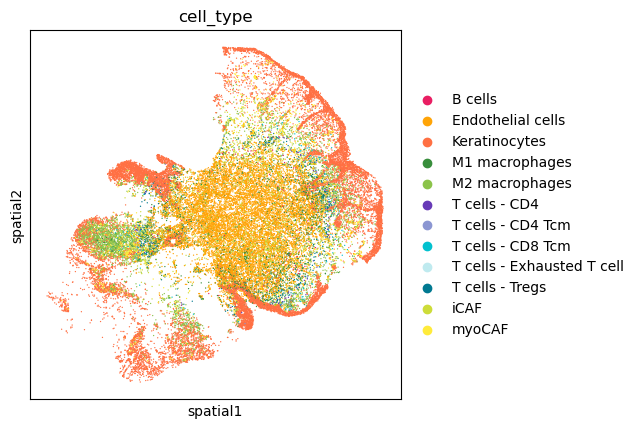

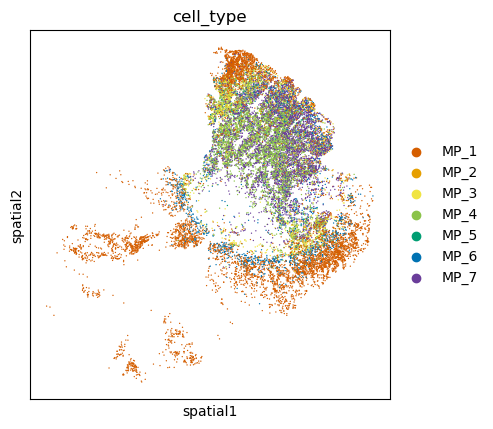

In [23]:
cell_type_colors = {
    "B cells": "#e91e63",
    "Plasma cells": "#ce93d8",
    "T cells - CD4": "#673ab7",
    "T cells - CD4 Tcm": "#8B96D2",
    "T cells - CD8": "#61ABEC",
    "T cells - CD8 Tcm": "#02c1cf",
    "T cells - Exhausted T cell": "#BFEAEF",
    "T cells - Tregs": "#007991",
    "M1 macrophages": "#388e3c",
    "M2 macrophages": "#8bc34a",
    "iCAF": "#cddc39",
    "myoCAF": "#ffeb3b",
    "Endothelial cells": "#ffa407",
    "Keratinocytes": "#ff7043",
    "Malignant": "firebrick",
    "Cycling cells": "grey80",
    'MP_1': "#D55E00",
    'MP_2': "#E69F00",
    'MP_3': "#F0E442",
    'MP_4': "#8BC34A",
    'MP_5': "#009E73",
    'MP_6': "#0072B2",
    'MP_7': "#6A3D9A",
    "T cells": "#007991",
    "Macrophages": "#8bc34a",
    "CAF": "#ffeb3b",
}
sc.pl.spatial(tme_sp, color='cell_type', spot_size=100, palette = cell_type_colors)
sc.pl.spatial(tumor_sp, color='cell_type', spot_size=100, palette = cell_type_colors)

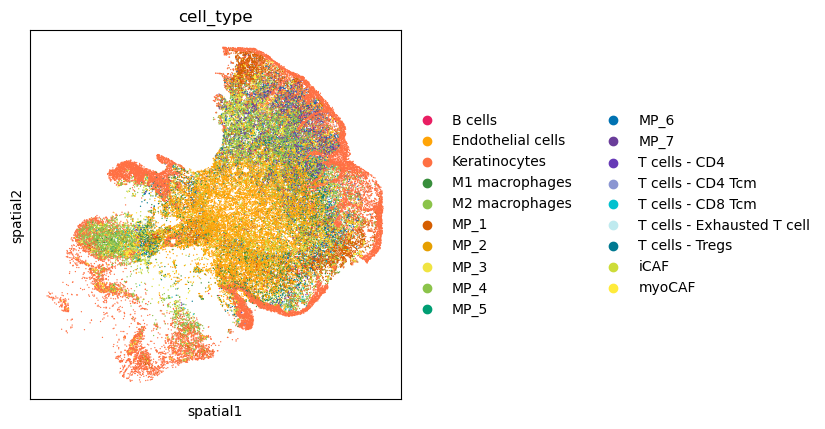

In [24]:
#merge and write adata
spatial_adata = anndata.concat([tumor_sp, tme_sp], axis=0)
sc.pl.spatial(spatial_adata, color='cell_type', palette=cell_type_colors, spot_size=100)

In [25]:
spatial_adata.write(data_directory + "/" + sample + "_" + um + "_programs.h5ad")